# 01_data_collection.ipynb
### Predictive Climate Intelligence: Data Acquisition Pipeline
**Project:** SkyCast | **Location:** Karachi, Pakistan
---

### 1. Environment Setup & API Configuration
*Installing dependencies and configuring the Open-Meteo cache session.*

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.0/211.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.5/772.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


### 2. Data Acquisition
*Fetching Air Quality and Meteorological data from Open-Meteo API.*

In [ ]:
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

# 1. SETUP API CLIENT (The "Digital Assistant")
# This creates a folder to remember data and a rule to try again if the internet fails
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# 2. DEFINE LOCATION (Karachi)
KARACHI_LAT = 24.8607
KARACHI_LON = 67.0011

print("=" * 50)
print("FETCHING KARACHI AQI & WEATHER DATA")
print("=" * 50)

# ============================================
# PART 1: GET AIR QUALITY DATA
# ============================================
print("\n1. Fetching air quality data...")

air_quality_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
aq_params = {
    "latitude": KARACHI_LAT,
    "longitude": KARACHI_LON,
    "start_date": "2023-01-01",
    "end_date": "2026-04-30",
    "hourly": [
        "pm10", "pm2_5",
        "carbon_monoxide", "nitrogen_dioxide",
        "ozone", "sulphur_dioxide",
        "us_aqi", "european_aqi"
    ]
}

# The website sends back a "box" of data. [0] means we grab the first result.
aq_response = openmeteo.weather_api(air_quality_url, params=aq_params)[0]
# We extract only the "Hourly" ledger of numbers
aq_hourly = aq_response.Hourly()

# We count the rows in the first column (Slot 0)
aq_length = len(aq_hourly.Variables(0).ValuesAsNumpy())

# Create a list of readable dates for every hour
aq_timestamps = pd.date_range(
    start=pd.to_datetime(aq_hourly.Time(), unit="s", utc=True),
    periods=aq_length,
    freq=pd.Timedelta(seconds=aq_hourly.Interval()),
    inclusive="left"
)

# Build the Table. Slot 0 is pm10, Slot 1 is pm2_5, etc.
aq_df = pd.DataFrame({
    "timestamp": aq_timestamps,
    "pm10": aq_hourly.Variables(0).ValuesAsNumpy(),
    "pm2_5": aq_hourly.Variables(1).ValuesAsNumpy(),
    "carbon_monoxide": aq_hourly.Variables(2).ValuesAsNumpy(),
    "nitrogen_dioxide": aq_hourly.Variables(3).ValuesAsNumpy(),
    "ozone": aq_hourly.Variables(4).ValuesAsNumpy(),
    "sulphur_dioxide": aq_hourly.Variables(5).ValuesAsNumpy(),
    "us_aqi": aq_hourly.Variables(6).ValuesAsNumpy(),
    "european_aqi": aq_hourly.Variables(7).ValuesAsNumpy()
})

# ============================================
# PART 2: GET WEATHER DATA
# ============================================
print("2. Fetching weather data...")

weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": KARACHI_LAT,
    "longitude": KARACHI_LON,
    "start_date": "2023-01-01",
    "end_date": "2026-04-31",
    "hourly": [
        "temperature_2m", "relative_humidity_2m",
        "wind_speed_10m", "pressure_msl",
        "precipitation", "cloudcover"
    ]
}

weather_response = openmeteo.weather_api(weather_url, params=weather_params)[0]
weather_hourly = weather_response.Hourly()
weather_length = len(weather_hourly.Variables(0).ValuesAsNumpy())

weather_timestamps = pd.date_range(
    start=pd.to_datetime(weather_hourly.Time(), unit="s", utc=True),
    periods=weather_length,
    freq=pd.Timedelta(seconds=weather_hourly.Interval()),
    inclusive="left"
)

weather_df = pd.DataFrame({
    "timestamp": weather_timestamps,
    "temperature": weather_hourly.Variables(0).ValuesAsNumpy(),
    "humidity": weather_hourly.Variables(1).ValuesAsNumpy(),
    "wind_speed": weather_hourly.Variables(2).ValuesAsNumpy(),
    "pressure": weather_hourly.Variables(3).ValuesAsNumpy(),
    "precipitation": weather_hourly.Variables(4).ValuesAsNumpy(),
    "cloudcover": weather_hourly.Variables(5).ValuesAsNumpy()
})



FETCHING KARACHI AQI & WEATHER DATA

1. Fetching air quality data...
2. Fetching weather data...


### 3. Data Integration & Merging
*Merging AQI and Weather datasets into a unified Master Dataframe.*

In [ ]:
# ============================================
# PART 3: MERGE (The Glue)
# ============================================
print("3. Merging tables...")
merged_df = pd.merge(aq_df, weather_df, on="timestamp", how="inner")
merged_df.insert(0, "city", "Karachi")

# ============================================
# PART 4: SAVE AND SHOW
# ============================================
csv_filename = "karachi_aqi_historical.csv"
merged_df.to_csv(csv_filename, index=False)

print(f"\n✅ SUCCESS! File saved as: {csv_filename}")
print("-" * 50)
print(f"Total Hours of Data: {len(merged_df)}")
print(f"Average Temperature: {merged_df['temperature'].mean():.1f}°C")
print(f"Average US AQI: {merged_df['us_aqi'].mean():.1f}")
print("-" * 50)

# Show the first few rows of the final spreadsheet
print("\nPreview of the data:")
print(merged_df.head())

3. Merging tables...

✅ SUCCESS! File saved as: karachi_aqi_historical.csv
--------------------------------------------------
Total Hours of Data: 29184
Average Temperature: 26.2°C
Average US AQI: 88.8
--------------------------------------------------

Preview of the data:
      city                 timestamp       pm10      pm2_5  carbon_monoxide  \
0  Karachi 2023-01-01 00:00:00+00:00  61.200001  36.599998            567.0   
1  Karachi 2023-01-01 01:00:00+00:00  57.000000  33.500000            668.0   
2  Karachi 2023-01-01 02:00:00+00:00  63.599998  38.799999            811.0   
3  Karachi 2023-01-01 03:00:00+00:00  66.599998  40.700001            967.0   
4  Karachi 2023-01-01 04:00:00+00:00  73.300003  45.500000           1028.0   

   nitrogen_dioxide  ozone  sulphur_dioxide      us_aqi  european_aqi  \
0         23.049999   76.0        26.950001  136.125000     79.960007   
1         30.250000   66.0        30.400000  136.093750     79.949997   
2         40.450001   53.0     

### 4. Initial Data Inspection
*verifying data types.*

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   city              29184 non-null  object             
 1   timestamp         29184 non-null  datetime64[ns, UTC]
 2   pm10              29184 non-null  float32            
 3   pm2_5             29184 non-null  float32            
 4   carbon_monoxide   29184 non-null  float32            
 5   nitrogen_dioxide  29184 non-null  float32            
 6   ozone             29184 non-null  float32            
 7   sulphur_dioxide   29184 non-null  float32            
 8   us_aqi            29184 non-null  float32            
 9   european_aqi      29184 non-null  float32            
 10  temperature       29184 non-null  float32            
 11  humidity          29184 non-null  float32            
 12  wind_speed        29184 non-null  float32            
 13  p

### 5. Data Quality & Integrity
*Verification of data consistency, null value analysis, and time-series continuity.*

In [ ]:
def clean_null_values(df):
    print("---  NULL VALUE ANALYSIS ---")

    # 1. Identify missing values
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]

    if null_cols.empty:
        print("No null values found. Dataset is clean.")
        return df

    print(f"Columns with missing values:\n{null_cols}")

    # 2. Apply cleaning strategy
    for col in null_cols.index:
        # Check percentage of missing data
        null_pct = df[col].isnull().mean()

        if null_pct < 0.05:
            # Drop rows if data is < 5% missing
            df = df.dropna(subset=[col])
            print(f"-> Dropped rows in '{col}' ({null_pct:.2%}).")
        else:
            # Impute with median for anything higher
            df[col] = df[col].fillna(df[col].median())
            print(f"-> Imputed '{col}' with median ({null_pct:.2%}).")

    print("--- ✅ CLEANING COMPLETE ---")
    return df

# Run the check
merged_df = clean_null_values(merged_df)

---  NULL VALUE ANALYSIS ---
No null values found. Dataset is clean.


In [ ]:
# Check if time stamps are consecutive
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'])
time_diffs = merged_df['timestamp'].diff().value_counts()
print(time_diffs.head())

timestamp
0 days 01:00:00    29183
Name: count, dtype: int64


### 6. Exploratory Data Analysis (EDA)
*Statistical summary and visualization of climate variables.*

--- 📊 DATASET STATISTICAL OVERVIEW ---


,us_aqi,pm2_5,pm10,temperature,humidity,wind_speed
count,29184.00,29184.00,29184.00,29184.00,29184.00,29184.00
mean,88.79,29.55,62.52,26.21,65.33,14.26
std,29.38,17.10,37.82,4.91,21.64,7.13
min,31.61,3.50,3.70,8.90,4.66,0.00
25%,68.00,19.20,39.10,23.25,50.67,8.89
50%,81.07,25.10,53.40,27.05,69.75,13.00
75%,102.05,34.70,74.70,29.65,83.16,18.68
max,297.38,339.00,497.30,41.55,100.00,46.64


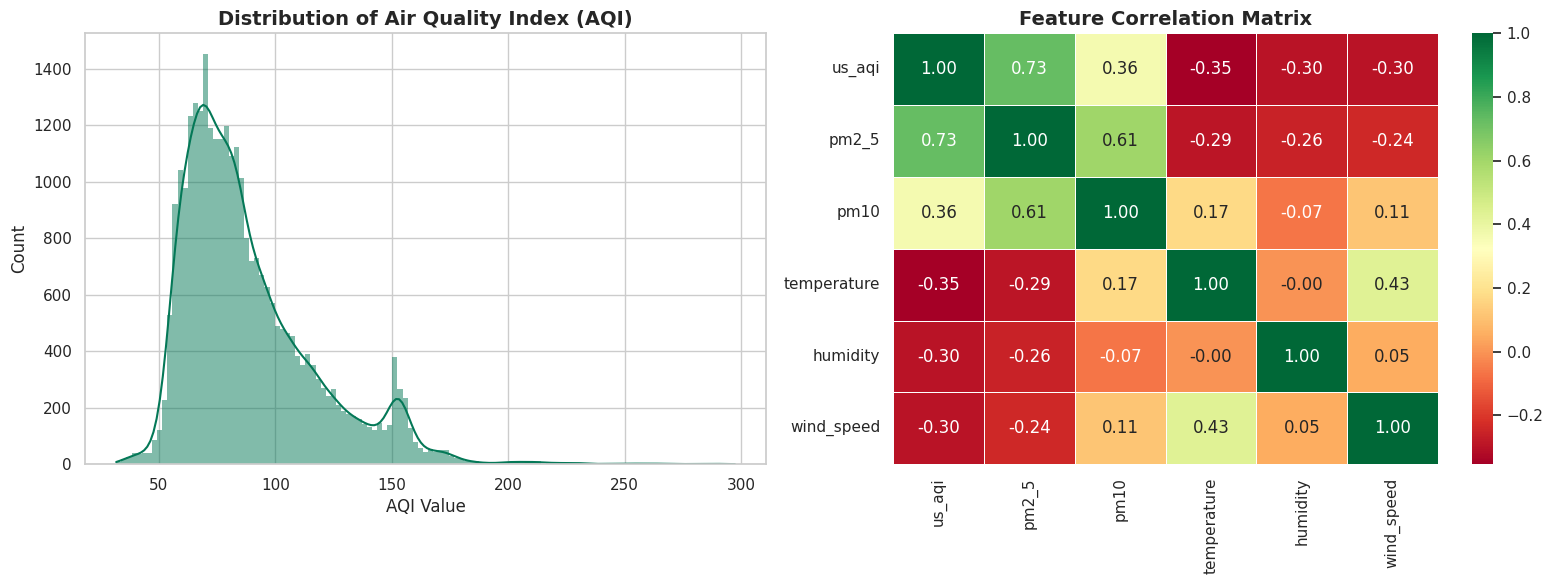

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Aesthetic for Professional Portfolio
sns.set_theme(style="whitegrid", font="sans-serif")
# Using colors consistent with your SkyCast dashboard theme
custom_palette = ["#047857", "#10b981", "#0ea5e9", "#f59e0b"]
sns.set_palette(custom_palette)

def run_complete_eda(df):
    print("--- 📊 DATASET STATISTICAL OVERVIEW ---")

    # 2. Key Statistical Summary
    # Focus on the most important columns for climate intelligence
    cols_to_analyze = ['us_aqi', 'pm2_5', 'pm10', 'temperature', 'humidity', 'wind_speed']
    display(df[cols_to_analyze].describe().round(2))

    # 3. Create a side-by-side visualization figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Visualization 1: AQI Distribution
    sns.histplot(df['us_aqi'], kde=True, ax=axes[0], color="#047857", linewidth=0)
    axes[0].set_title('Distribution of Air Quality Index (AQI)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('AQI Value')

    # Visualization 2: Correlation Heatmap
    # We use only numeric features for the correlation matrix
    corr = df[cols_to_analyze].corr()
    sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5, ax=axes[1])
    axes[1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()


# RUN THE ANALYSIS
run_complete_eda(merged_df)